In [21]:
#Pavankumar Shinde
#CO22BTECH11008

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.integrate import simps
E = 4500
p0 = 100
N = 200  #number of internal grid points
delta_q = 1 / 201
delta_s = delta_q / 2000

q = np.linspace(-0.5, 0.5, N + 2)  #including boundary points
V = np.zeros_like(q) # potential
V[q > 1/8] = 5000
V[0] = np.inf  #at Boundaries


In [ ]:

Psi_0 = (2 / np.pi)**(0.25) * (E - (p0**2) / 4)**(0.25) * \
    np.exp(-(E - (p0**2) / 4) * q**2) * np.exp(1j * (p0 / 2) * q)
Psi_0[0] = Psi_0[-1] = 0  # Psi=0 at q=-1/2 and q=1/2

In [ ]:

#Crank-Nicolson matrices
alpha = -1j * delta_s / (2 * delta_q**2)  # coefficient for the second derivative operator
beta = -1j * delta_s / 2 # scales the potential term

A = np.zeros((N, N), dtype=complex)
B = np.zeros((N, N), dtype=complex)

for i in range(N):
    # main diagonal
    A[i, i] = 1 - beta * V[i + 1] + 2 * alpha
    B[i, i] = 1 + beta * V[i + 1] - 2 * alpha
    
    #off-diagonals
    if i > 0:
        A[i, i - 1] = -alpha
        B[i, i - 1] = alpha
    if i < N - 1:
        A[i, i + 1] = -alpha
        B[i, i + 1] = alpha
   

In [17]:
     
Psi = Psi_0[1:-1].copy()
steps_to_plot = [0, 200, 400, 600, 800, 1000]
probability_distributions = []
integrals = []
for step in range(1001):
    #using Crank-Nicolson method
    rhs = B @ Psi
    Psi_next = np.linalg.solve(A, rhs)
    Psi[:] = Psi_next

   
    Psi_full = np.zeros_like(q, dtype=complex)
    Psi_full[1:-1] = Psi

    # Probability Distribution
    prob_dist = np.abs(Psi_full)**2
    integral_prob_dist = simps(prob_dist, q)
    
    integrals.append(integral_prob_dist)

    if step in steps_to_plot:
        probability_distributions.append((q.copy(), prob_dist.copy()))
        


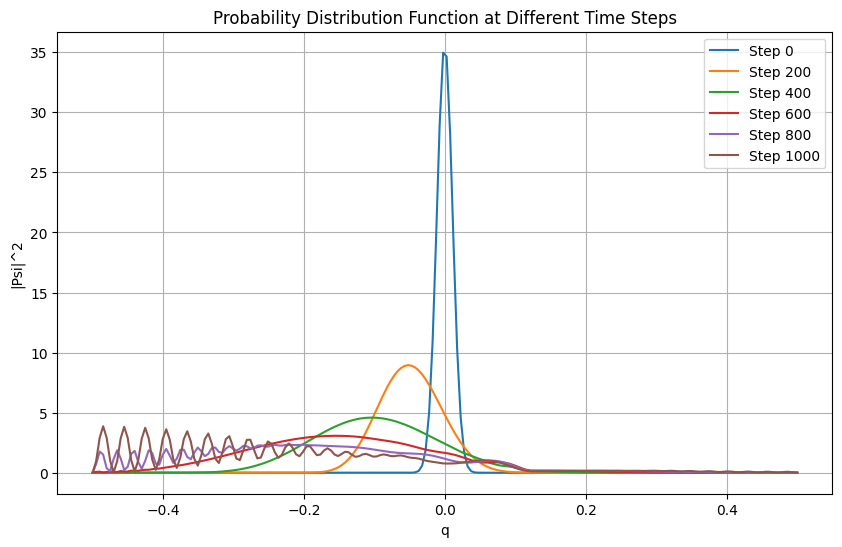

In [25]:
#probability distributions
plt.figure(figsize=(10, 6))
for i, (q_vals, prob_dist) in enumerate(probability_distributions):
    plt.plot(q_vals, prob_dist, label=f"Step {steps_to_plot[i]}")
plt.xlabel("q")
plt.ylabel(r"|Psi|^2")
plt.title("Probability Distribution Function at Different Time Steps")
plt.legend()
plt.grid()
plt.show()

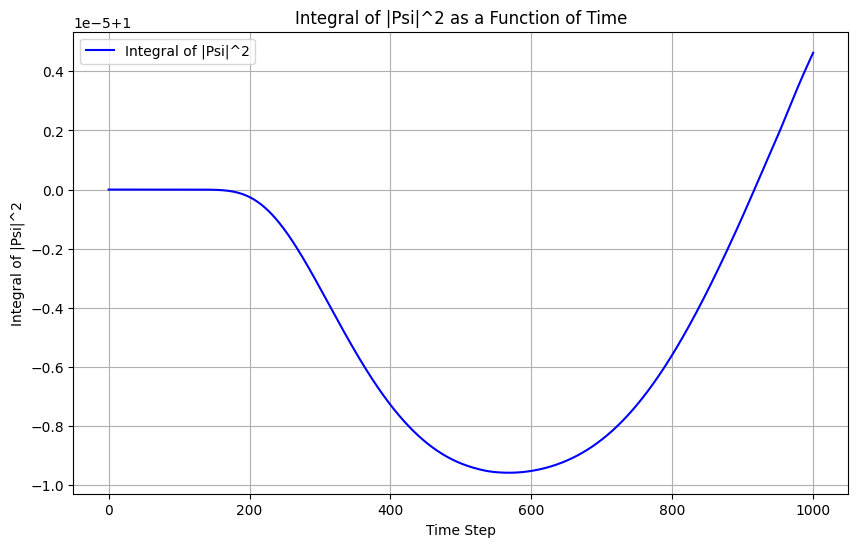

In [23]:

plt.figure(figsize=(10, 6))
plt.plot(range(1001), integrals, label=r"Integral of |Psi|^2", color="blue")
plt.xlabel("Time Step")
plt.ylabel(r"Integral of |Psi|^2")
plt.title(r"Integral of |Psi|^2 as a Function of Time")
plt.legend()
plt.grid()
plt.show()